In [3]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [4]:
template_path           = '/scratch/leiff/MCA/data/rlut_mon_CanESM5_historical_r1i1p1f1_g025.nc'
filepath_output_ceres   = '/scratch/leiff/MCA/amip_clean/data/CERES/CERES_net_200003-202604_g025.nc'
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'

In [5]:
ERA5    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
        "t2m": "tas",})
CERES   = xc.open_dataset(filepath_output_ceres).drop_vars(('toa_sw_all_mon','toa_lw_all_mon','toa_sw_clr_c_mon',
        'toa_lw_clr_c_mon','toa_net_clr_c_mon','solar_mon','cldarea_total_daynight_mon','cldpress_total_daynight_mon',
        'cldtemp_total_daynight_mon','cldtau_total_day_mon')).sel(time=slice('2000-03','2014-12')).rename_vars({
        "toa_net_all_mon": "N",})

In [6]:
ERA5['weights'] = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
ERA5['T']       = np.sum(ERA5['tas']*ERA5['weights'],axis=(1,2))/np.sum(ERA5['weights'])
CERES['Ng']     = np.sum(CERES['N']*ERA5['weights'],axis=(1,2))/np.sum(ERA5['weights'])

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
weights_1D  = np.array(ERA5['weights'].data).reshape(n_flat)
print(n_time,n_lat,n_lon,n_flat)

178 72 144 10368


In [7]:
# Move spatial and global N and tas into detrended anomalies
tas_obs = detrend_monthly_fast(np.array(ERA5['tas'].data))
N_obs   = detrend_monthly_fast(np.array(CERES['N'].data))

tas_obs_reshaped    = tas_obs.reshape(n_time,n_flat)
N_obs_reshaped      = N_obs.reshape(n_time,n_flat)

T_obs   = detrend_monthly_fast(np.array(ERA5['T'].data))
Ng_obs  = detrend_monthly_fast(np.array(CERES['Ng'].data))

In [8]:
# Calcualte the three quantities
covRTi_obs          = MCA_dave(tas_obs_reshaped, Ng_obs, weights_1D, standardized=True).reshape(n_lat,n_lon)
covTRi_obs          = MCA_dave(N_obs_reshaped, T_obs, weights_1D, standardized=True).reshape(n_lat,n_lon)
_,_,regTiRi_obs,_   = lag_linregress_3D(tas_obs,N_obs)

In [16]:
# plot_3_observation_maps

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def plot_3_observation_maps(
    maps,
    lat,
    lon,
    panel_titles,
    *,
    figure_title="Observations",
    colorbar_labels=None,
    cmaps="RdBu_r",
    vlims=None,
    robust_percentile=98,
    number_of_levels=21,
    central_longitude=0,
    savepath=None,
    dpi=200,
):
    """
    Plot three observational maps vertically.

    Parameters
    ----------
    maps
        List of three arrays, each shaped (lat, lon).
    lat, lon
        One-dimensional spatial coordinates.
    panel_titles
        Three panel titles in top-to-bottom order.
    colorbar_labels
        Three colorbar labels. Defaults to blank labels.
    cmaps
        One colormap name or a list of three colormap names.
    vlims
        Three symmetric absolute color limits. Use None for automatic robust
        limits, for example [None, None, None]. A single number applies to all.
    savepath
        Optional output filename.
    """
    if len(maps) != 3:
        raise ValueError(
            f"Expected three maps, received {len(maps)}"
        )

    if len(panel_titles) != 3:
        raise ValueError(
            "panel_titles must contain exactly three titles"
        )

    maps = np.stack(
        [np.asarray(model_map) for model_map in maps],
        axis=0,
    )

    lat = np.asarray(lat)
    lon = np.asarray(lon)

    if maps.shape[1:] != (len(lat), len(lon)):
        raise ValueError(
            f"Map shape {maps.shape[1:]} does not match "
            f"lat/lon lengths {(len(lat), len(lon))}"
        )

    if colorbar_labels is None:
        colorbar_labels = ["", "", ""]

    if len(colorbar_labels) != 3:
        raise ValueError(
            "colorbar_labels must contain exactly three labels"
        )

    if isinstance(cmaps, str):
        cmaps = [cmaps] * 3

    if len(cmaps) != 3:
        raise ValueError(
            "cmaps must be one name or a list of three names"
        )

    if vlims is None:
        vlims = [None, None, None]
    elif np.isscalar(vlims):
        vlims = [float(vlims)] * 3
    else:
        vlims = list(vlims)

    if len(vlims) != 3:
        raise ValueError(
            "vlims must be one number or a list of three values"
        )

    projection = ccrs.Robinson(
        central_longitude=central_longitude
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 11.5),
        subplot_kw={"projection": projection},
        constrained_layout=True,
    )

    for panel_index, ax in enumerate(axes):
        panel_map = maps[panel_index]
        panel_vlim = vlims[panel_index]

        # Derive a robust, symmetric color scale for this diagnostic.
        if panel_vlim is None:
            finite_values = np.abs(
                panel_map[np.isfinite(panel_map)]
            )

            if finite_values.size == 0:
                raise ValueError(
                    f"Panel {panel_index + 1} has no finite values"
                )

            panel_vlim = np.percentile(
                finite_values,
                robust_percentile,
            )

            if panel_vlim == 0:
                panel_vlim = np.max(finite_values)

            if panel_vlim == 0:
                panel_vlim = 1.0

        levels = np.linspace(
            -panel_vlim,
            panel_vlim,
            number_of_levels,
        )

        # Add a cyclic longitude point to remove the map seam.
        if np.isclose(
            abs(lon[-1] - lon[0]),
            360.0,
        ):
            plot_map = panel_map
            plot_lon = lon
        else:
            plot_map, plot_lon = add_cyclic_point(
                panel_map,
                coord=lon,
                axis=-1,
            )

        mappable = ax.contourf(
            plot_lon,
            lat,
            plot_map,
            levels=levels,
            cmap=cmaps[panel_index],
            extend="both",
            transform=ccrs.PlateCarree(),
        )

        # norm = mpl.colors.BoundaryNorm(
        #     levels,
        #     ncolors=mpl.colormaps[cmaps[panel_index]].N,
        #     clip=False,
        # )

        # mappable = ax.pcolormesh(
        #     plot_lon,
        #     lat,
        #     plot_map,
        #     cmap=cmaps[panel_index],
        #     norm=norm,
        #     shading="auto",
        #     transform=ccrs.PlateCarree(),
        # )

        ax.set_global()
        ax.coastlines(
            resolution="110m",
            linewidth=0.55,
            color="0.2",
        )

        ax.gridlines(
            linewidth=0.3,
            color="0.35",
            alpha=0.4,
            linestyle=":",
        )

        panel_letter = chr(ord("a") + panel_index)

        ax.set_title(
            f"({panel_letter}) {panel_titles[panel_index]}",
            fontsize=14,
            pad=5,
        )

        colorbar = fig.colorbar(
            mappable,
            ax=ax,
            orientation="horizontal",
            pad=0.035,
            fraction=0.055,
            aspect=35,
            extend="both",
        )

        colorbar.set_label(
            colorbar_labels[panel_index],
            fontsize=12,
        )

        colorbar.ax.tick_params(
            labelsize=9,
        )

    fig.suptitle(
        figure_title,
        fontsize=16,
    )

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            savepath,
            dpi=dpi,
            bbox_inches="tight",
        )

        print(f"Saved: {savepath}")

    return fig, axes

Saved: data/maps_2000_2014/obs/threeMaps_obs


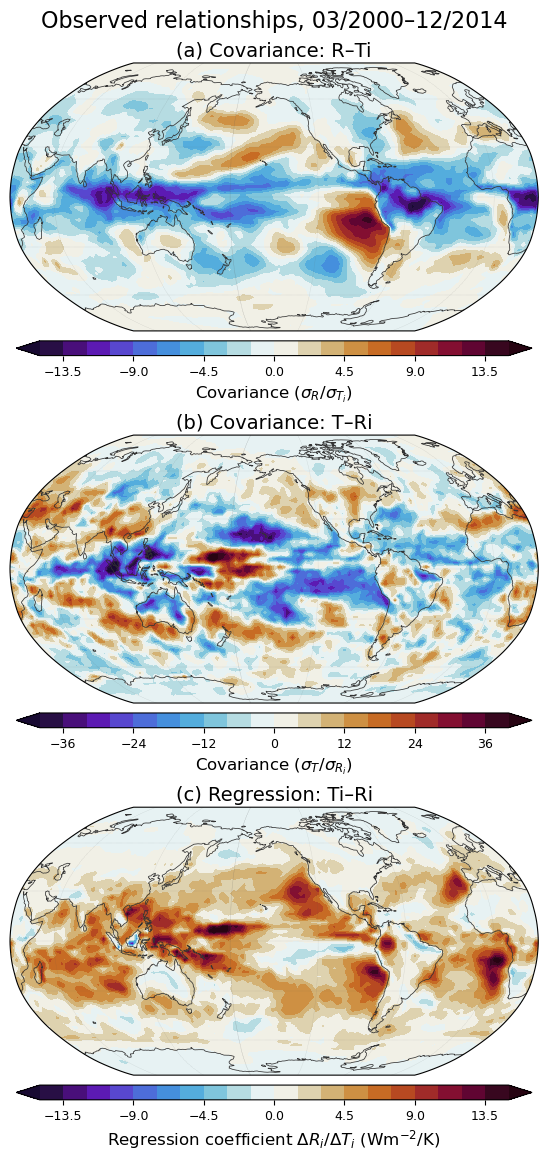

In [17]:
fig, axes = plot_3_observation_maps(
    maps=[
        covRTi_obs,
        covTRi_obs,
        regTiRi_obs,
    ],
    lat=ERA5.lat,
    lon=ERA5.lon,
    panel_titles=[
        "Covariance: R–Ti",
        "Covariance: T–Ri",
        "Regression: Ti–Ri",
    ],
    colorbar_labels=[
        r"Covariance ($\sigma_{R}/\sigma_{T_i}$)",
        r"Covariance ($\sigma_{T}/\sigma_{R_i}$)",
        r"Regression coefficient $\Delta R_i / \Delta T_i$ (Wm$^{-2}$/K)",
    ],
    figure_title="Observed relationships, 03/2000–12/2014",
    central_longitude=210,
    cmaps="cmr.fusion_r",
    vlims = [15,40,15],
    savepath = "./data/maps_2000_2014/obs/threeMaps_obs"
)